In [3]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from skbio import DistanceMatrix
from skbio.stats.ordination import pcoa


# Configure 

In [4]:
HAS_GROUPS = True
WORKDIR = '/home/p/code/codon_usage'

# QC
Assembly summary statistics were calculated with `seqkit stats` and used for a basic quality assessment across samples.


If samples belong to different groups, the group label can be added as a prefix in the file name. For example: `group1_ecoli.fasta`

In [58]:
def add_groups(df: pd.DataFrame, file_name_col: str | None = None) -> pd.DataFrame:
    df = df.copy()
    if HAS_GROUPS:
        if file_name_col is None:
            df['group'] = df.index.str.split('_').str[0]
        else:
            df['group'] = df[file_name_col].str.split('_').str[0]
    else:
        df['group'] = 'all' 
    
    return df

In [26]:
target_metrics = ['num_seqs','N50','N50_num', 'GC(%)',] # add here more metrics if needed
n_metrics = len(target_metrics)
ncols = 2
nrows = math.ceil(n_metrics / ncols)

In [ ]:
qc_df = pd.read_csv(f'{WORKDIR}/assembly_stats.tsv', sep=r'\s+')
qc_df['N50'] = qc_df['N50'].str.replace(',', '', regex=False).astype(int)
qc_df = add_groups(qc_df, 'file')

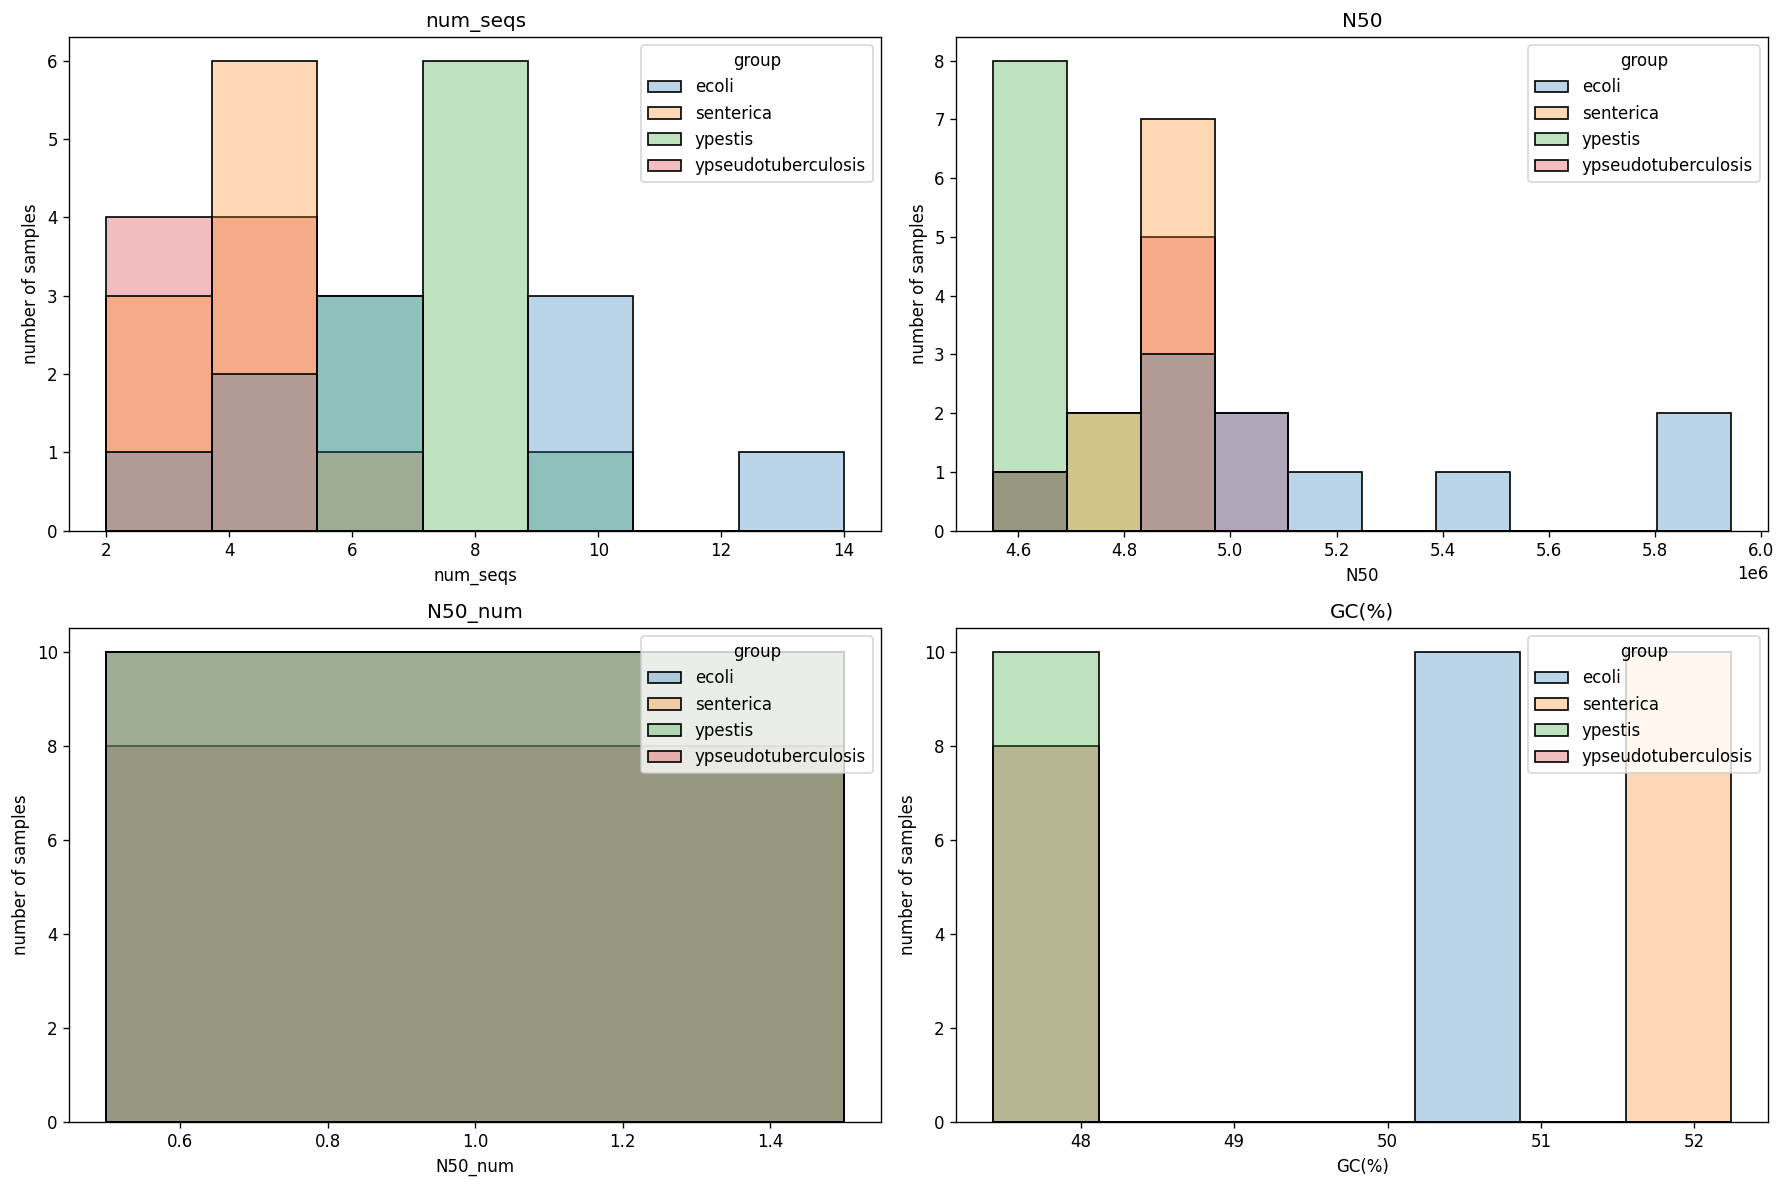

In [ ]:
fig, axs = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows), dpi=120)
axs = axs.ravel()

for num, metric in enumerate(target_metrics):
    ax = axs[num]

    qc_plot_kwargs = {
        'data': qc_df,
        'x': metric,
        'ax': ax
    }
    if HAS_GROUPS:
        qc_plot_kwargs['hue'] = 'group'
        qc_plot_kwargs['multiple'] = 'layer'
        qc_plot_kwargs['alpha'] = 0.3
    
    sns.histplot(**qc_plot_kwargs)
    ax.set_xlabel(metric)
    ax.set_ylabel('Number of samples')
    ax.set_title(metric)

for i in range(n_metrics, len(axs)):
    fig.delaxes(axs[i])
    
plt.tight_layout()


# Annotate CDS

CDS annotation was tested with `prokka`, but other annotation tools can also be used. The downstream analysis is based on CDS nucleotide FASTA files (`.ffn` in the `prokka` output).

For the CDS count QC step, a table with file names and total CDS counts is required.

For more details, see the README or `prepare_data.sh`.


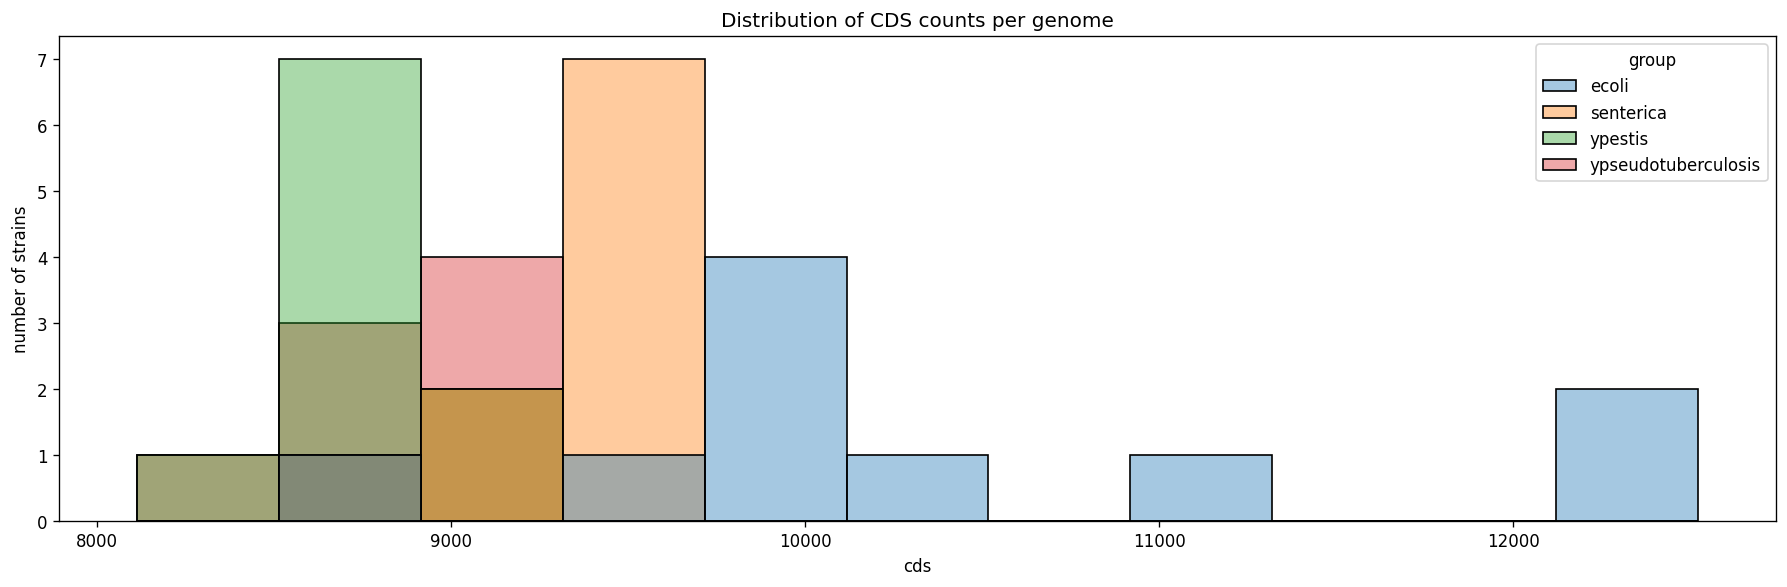

In [ ]:
cds = pd.read_csv(f'{WORKDIR}/cds.txt', sep=':', header=None, names=['file','cds'])
cds['cds'] = cds['cds'].astype(int)
cds = add_groups(cds, 'file')

cds_plot_kwargs = {
    'data': cds,
    'x': 'cds'
}

if HAS_GROUPS:
    cds_plot_kwargs['hue'] = 'group'
    cds_plot_kwargs['multiple'] = 'layer'
    cds_plot_kwargs['alpha'] = 0.4

plt.figure(figsize=(15, 5), dpi=120)
sns.histplot(**cds_plot_kwargs)
plt.xlabel('Number of CDS')
plt.ylabel('Number of strains')
plt.title('Distribution of CDS counts per genome')
plt.tight_layout()

## Codon usage analysis

Codon usage tables were calculated with `EMBOSS cusp` and used for downstream analysis.

The preprocessing steps are described in `prepare_data.sh` and in the README.

> NOTE: t-SNE is used here as an additional exploratory nonlinear embedding method to visualize potential local structure in codon usage patterns that may not be apparent in PCA. The main method of interpretation in this section is PCA.

In [ ]:
def extract_codon_frequencies(sample_table: pd.DataFrame, strain_name: str) -> pd.DataFrame:
    frequency_df = (sample_table.rename(columns={'Frequency':strain_name})
                           .set_index('Codon')
                           .T
                           .drop(['AA', 'Fraction', 'Number'])
                           )

    return frequency_df

def calculate_rscu(sample_table:pd.DataFrame, sample_name: str) -> pd.DataFrame:

    sample_table = sample_table[sample_table['AA'] != '*'].copy()
    sample_table['AA_total'] = sample_table.groupby('AA')['Number'].transform('sum')
    sample_table['AA_ncodons'] = sample_table.groupby('AA')['Codon'].transform('count')

    sample_table['RSCU'] = (sample_table['Number'] * sample_table['AA_ncodons']) / sample_table['AA_total']

    rscu_sum = sample_table.groupby('AA')['RSCU'].sum()
    n_codons = sample_table.groupby('AA')['Codon'].count()


    check = np.isclose(rscu_sum, n_codons)
    if not check.all():
        raise ValueError(f"RSCU check failed for sample {sample_name}")    
    
    sample_table =  sample_table.set_index('Codon')
    res = sample_table['RSCU'].to_frame().T
    res.index = [sample_name]
    return res

def calculate_enc(sample_table:pd.DataFrame, sample_name: str) -> pd.DataFrame:
    df = sample_table.loc[sample_table['AA'] != '*'].copy()

    f_by_family = {2: [], 3: [], 4: [], 6: []}

    for aa, aa_df in df.groupby('AA'):
        n = aa_df.shape[0]
        
        if n not in f_by_family:
            continue

        total = aa_df['Number'].sum()
        if total == 0:
            continue
        
        p = aa_df['Number'] / total
        f = np.sum(p ** 2)
        f_by_family[n].append(f)
    
    for family in f_by_family:
        if not f_by_family[family]:
            raise ValueError(f'ENC cannot be calculated for sample {sample_name}: missing {family}-fold codon family')
            
    F2 = np.mean(f_by_family[2])
    F3 = np.mean(f_by_family[3])
    F4 = np.mean(f_by_family[4])
    F6 = np.mean(f_by_family[6])

    enc = 2 + (9 / F2) + (1 / F3) + (5 / F4) + (3 / F6)

    return pd.DataFrame({'enc':[enc]}, index=[sample_name])

In [83]:
frequencies_info = []
rscu_info  = [] 
enc_info = []

for strain in os.listdir(f'{WORKDIR}/freq'):
    cur_path = f'{WORKDIR}/freq/{strain}'
    
    strain_name = os.path.splitext(os.path.split(cur_path)[1])[0]
    strain_df = pd.read_csv(cur_path, comment='#', sep=r'\s+',
                                     names=['Codon','AA','Fraction','Frequency','Number'])
    
    cur_freq_df = extract_codon_frequencies(strain_df, strain_name)
    strain_rscu = calculate_rscu(strain_df, strain_name)
    strain_enc = calculate_enc(strain_df, strain_name)
    
    
    frequencies_info.append(cur_freq_df) 
    rscu_info.append(strain_rscu)
    enc_info.append(strain_enc)


frequencies_df = add_groups(pd.concat(frequencies_info))
rscu_df = add_groups(pd.concat(rscu_info)) 
enc_df = add_groups(pd.concat(enc_info)) 

In [52]:
frequencies_df

Codon,GCA,GCC,GCG,GCT,TGC,TGT,GAC,GAT,GAA,GAG,...,GTC,GTG,GTT,TGG,TAC,TAT,TAA,TAG,TGA,group
ypestis_CMCCK110001,21.055,26.777,23.761,19.633,4.794,5.648,14.508,36.447,34.648,20.543,...,15.474,22.551,19.093,13.648,10.207,19.759,1.901,0.56,1.094,ypestis
senterica_ATCC_13311,12.943,28.981,42.539,12.807,6.716,4.938,20.02,31.722,35.263,20.484,...,18.265,24.918,15.716,15.259,11.403,17.137,2.058,0.389,1.189,senterica
ypestis_Shasta,20.959,26.867,23.818,19.712,4.776,5.66,14.475,36.584,34.541,20.519,...,15.531,22.555,19.077,13.646,10.122,19.726,1.902,0.568,1.085,ypestis
ypestis_A1122,21.044,26.889,23.781,19.769,4.763,5.647,14.447,36.721,34.547,20.47,...,15.533,22.656,19.073,13.59,10.147,19.747,1.915,0.564,1.059,ypestis
ecoli_ATCC11775,20.676,25.527,32.812,15.625,6.317,5.267,19.21,32.233,39.29,18.092,...,15.171,25.911,18.448,15.446,12.077,16.234,2.121,0.309,1.14,ecoli
ypestis_FDAARGOS_601,21.18,26.742,23.751,19.634,4.78,5.579,14.61,36.291,34.645,20.588,...,15.479,22.536,19.058,13.581,10.151,19.722,1.923,0.579,1.152,ypestis
ypseudotuberculosis_FDAARGOS_342,20.542,27.099,23.637,19.8,4.721,5.728,14.391,37.248,34.143,20.269,...,15.493,22.659,18.946,13.925,9.923,19.573,1.892,0.609,1.095,ypseudotuberculosis
senterica_LT2,12.999,29.167,42.336,12.728,6.719,4.917,20.299,31.511,35.106,20.66,...,18.237,25.18,15.48,15.304,11.524,17.033,2.035,0.392,1.199,senterica
ecoli_UTI89,20.913,25.425,32.704,15.742,6.281,5.284,19.132,32.352,39.205,18.162,...,15.09,25.864,18.445,15.425,12.061,16.36,2.096,0.303,1.145,ecoli
ypestis_Dodson,20.93,26.891,23.793,19.703,4.805,5.725,14.293,36.658,34.494,20.41,...,15.535,22.588,19.006,13.66,10.078,19.779,1.907,0.579,1.111,ypestis


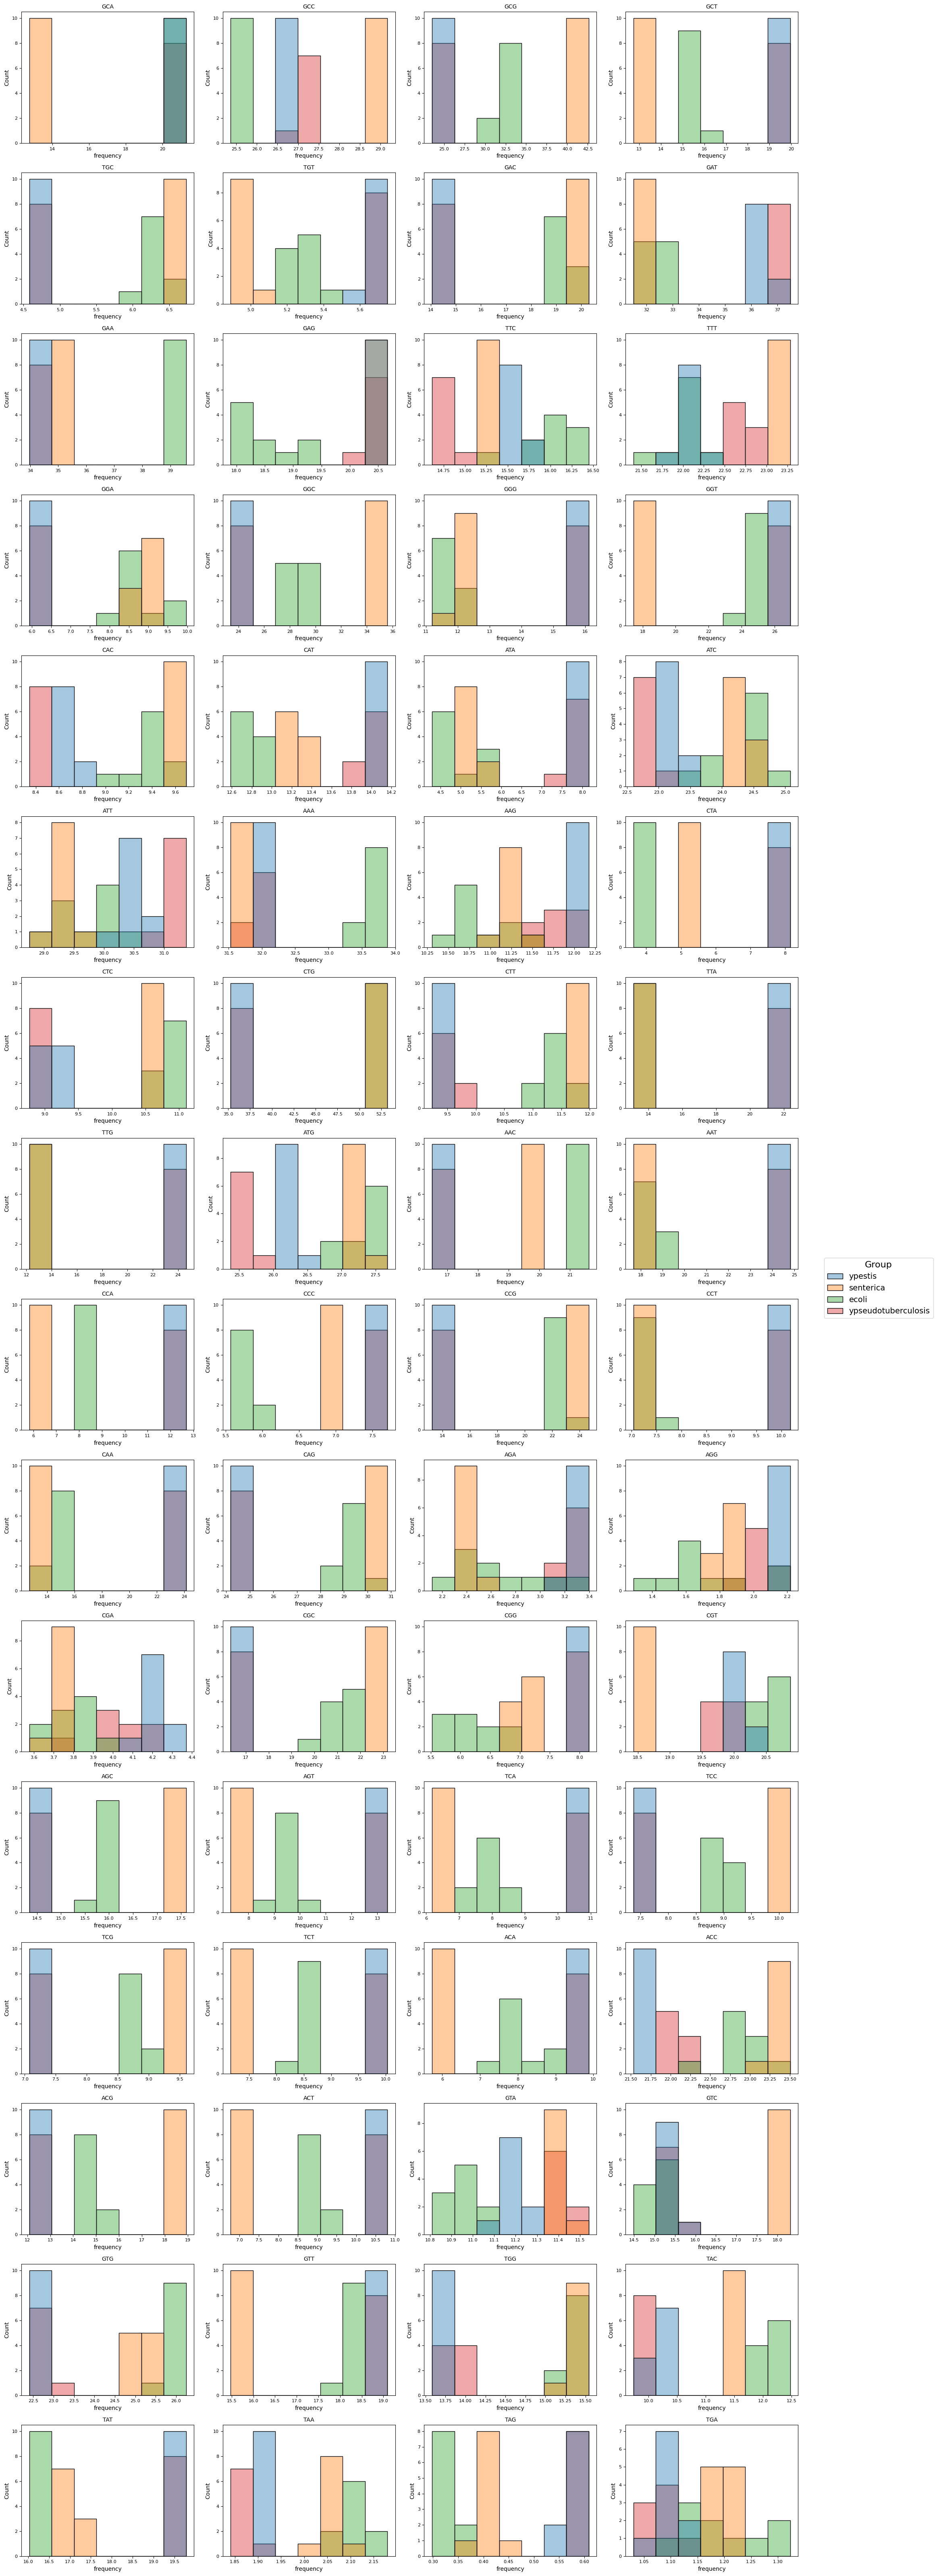

In [ ]:
fig, axs = plt.subplots(16, 4, figsize=(20, 4 * 16), dpi=100)
axs = axs.ravel()

handles, labels = None, None

for num, codon in enumerate(frequencies_df.columns.drop('group')):
    ax = axs[num]
    sns.histplot(data=frequencies_df, x=codon, ax=ax, hue='group', alpha=0.4, legend=(num == 0))


    if num == 0 and ax.legend_ is not None:
        handles = ax.legend_.legend_handles
        labels = [t.get_text() for t in ax.legend_.texts]
    

    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_xlabel('Frequency')
    ax.set_title(codon, fontsize=10)
    ax.tick_params(labelsize=8)

if handles is not None and labels is not None:
    fig.legend(
        handles,
        labels,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        title='Group',
        fontsize=14,
        title_fontsize=16
    )
    
plt.tight_layout()



In [ ]:
scaler = StandardScaler()
X = frequencies_df.drop('group', axis=1).astype(float)
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(columns=['PC1','PC2'], data=X_pca)
pca_df['group'] = frequencies_df['group'].reset_index(drop=True).astype(str)
pca_df.index = frequencies_df.index
explained_ratio = pca.explained_variance_ratio_
print(f'Total explained ratio:{sum(explained_ratio): .2%}')

Total explained ratio: 94.43%


In [54]:
tsne_res = TSNE(n_components=2, perplexity=30, max_iter=5000, random_state=27).fit_transform(X_scaled)
tsne_df = pd.DataFrame(columns=['TSNE1','TSNE2'], data=tsne_res)
tsne_df['group'] = frequencies_df['group'].reset_index(drop=True).astype(str)
tsne_df.index = frequencies_df.index

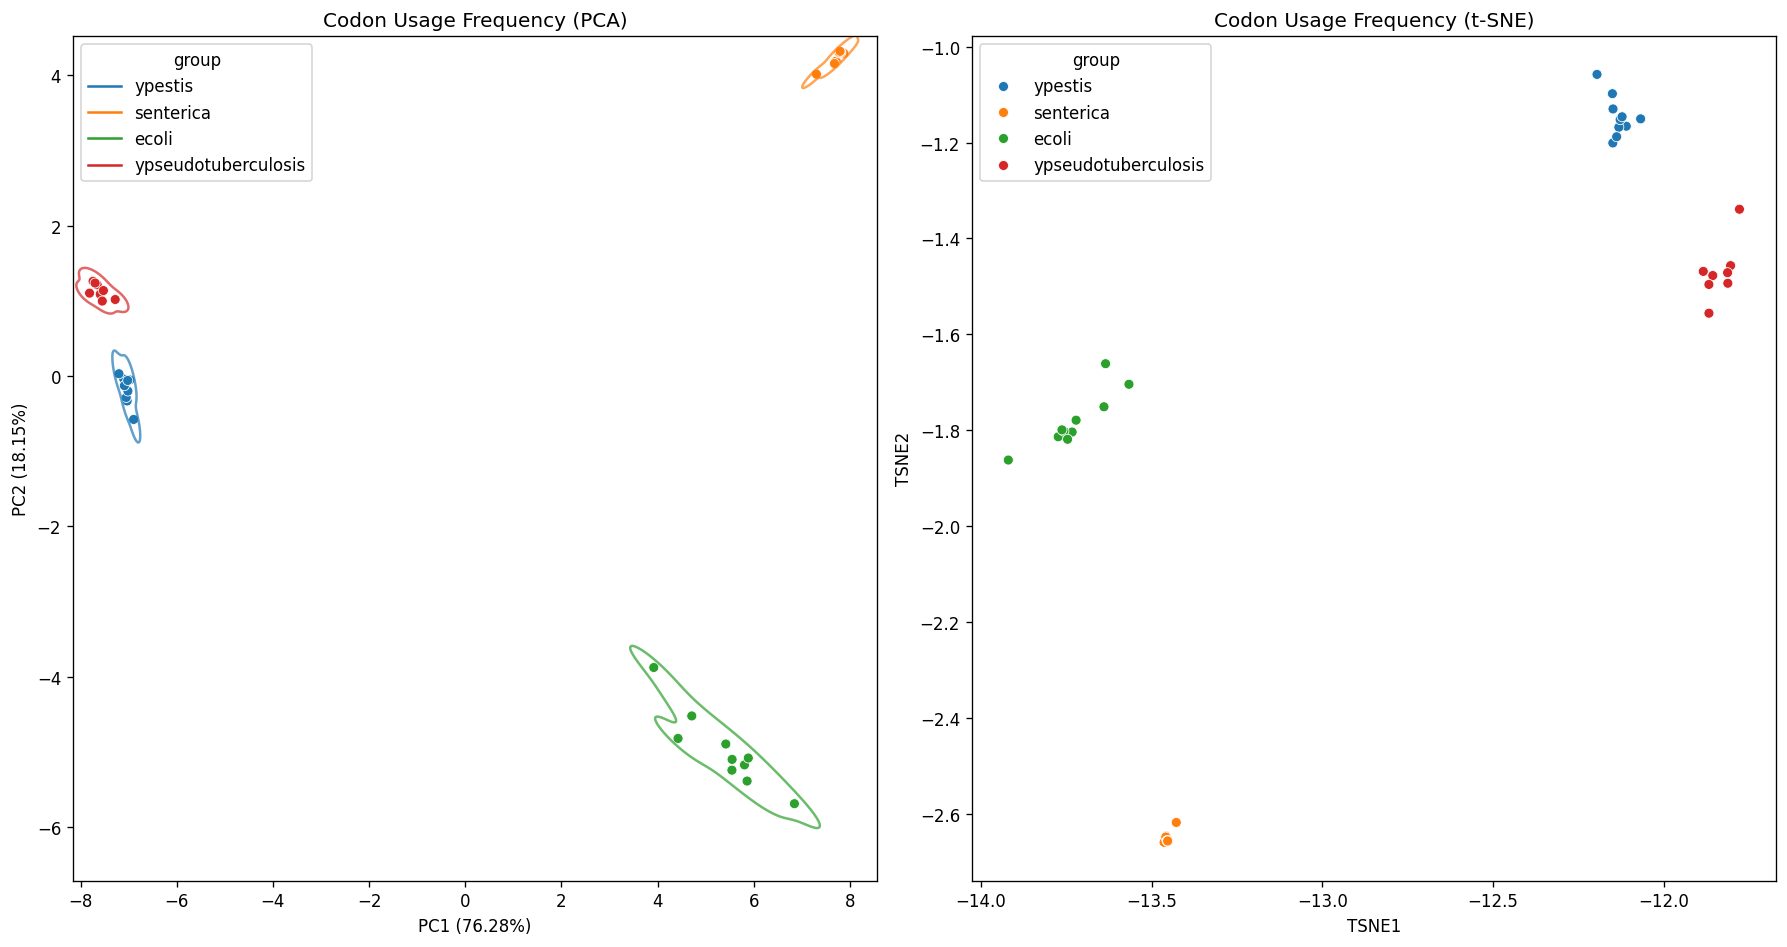

In [77]:
fig, axs = plt.subplots(1, 2, figsize=(15, 8), dpi=120)
axs = axs.ravel()

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='group', ax=axs[0])
sns.kdeplot(data=pca_df, x='PC1', y='PC2', hue='group', levels=1, alpha=0.7, thresh=0.01, ax=axs[0]) # Optional: disable KDE contours if group sizes are too small
axs[0].set_xlabel(f'PC1 ({explained_ratio[0]:.2%})')
axs[0].set_ylabel(f'PC2 ({explained_ratio[1]:.2%})')
axs[0].set_title('Codon Usage Frequency (PCA)')

sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='group', ax=axs[1])
axs[1].set_title('Codon Usage Frequency (t-SNE)')

plt.tight_layout()


# Relative Synonymous Codon Usage (RSCU)

In [ ]:
rscu_pca = PCA(n_components=2)
rscu_scaler = StandardScaler()

X_rscu = rscu_scaler.fit_transform(rscu_df.drop('group', axis=1))
rscu_df_scaled = pd.DataFrame(index=rscu_df.index, columns=rscu_df.columns[:-1], data=X_rscu)

rscu_pca_res = rscu_pca.fit_transform(rscu_df_scaled)
rscu_pca_df = pd.DataFrame(columns=['PC1','PC2'], data=rscu_pca_res, index=rscu_df.index)
rscu_pca_df['group'] = rscu_df['group']

rscu_explained_ratio = rscu_pca.explained_variance_ratio_
print(f'Total explained ratio:{sum(rscu_explained_ratio): .2%}')

Total explained ratio: 95.59%


In [64]:
tsne_rscu = TSNE(n_components=2, perplexity=30, max_iter=5000, random_state=26)
rscu_tsne = tsne_rscu.fit_transform(X_rscu)
rscu_tsne_df = pd.DataFrame(columns=['TSNE1','TSNE2'], data=rscu_tsne, index=rscu_df.index)
rscu_tsne_df['group'] = rscu_df['group']

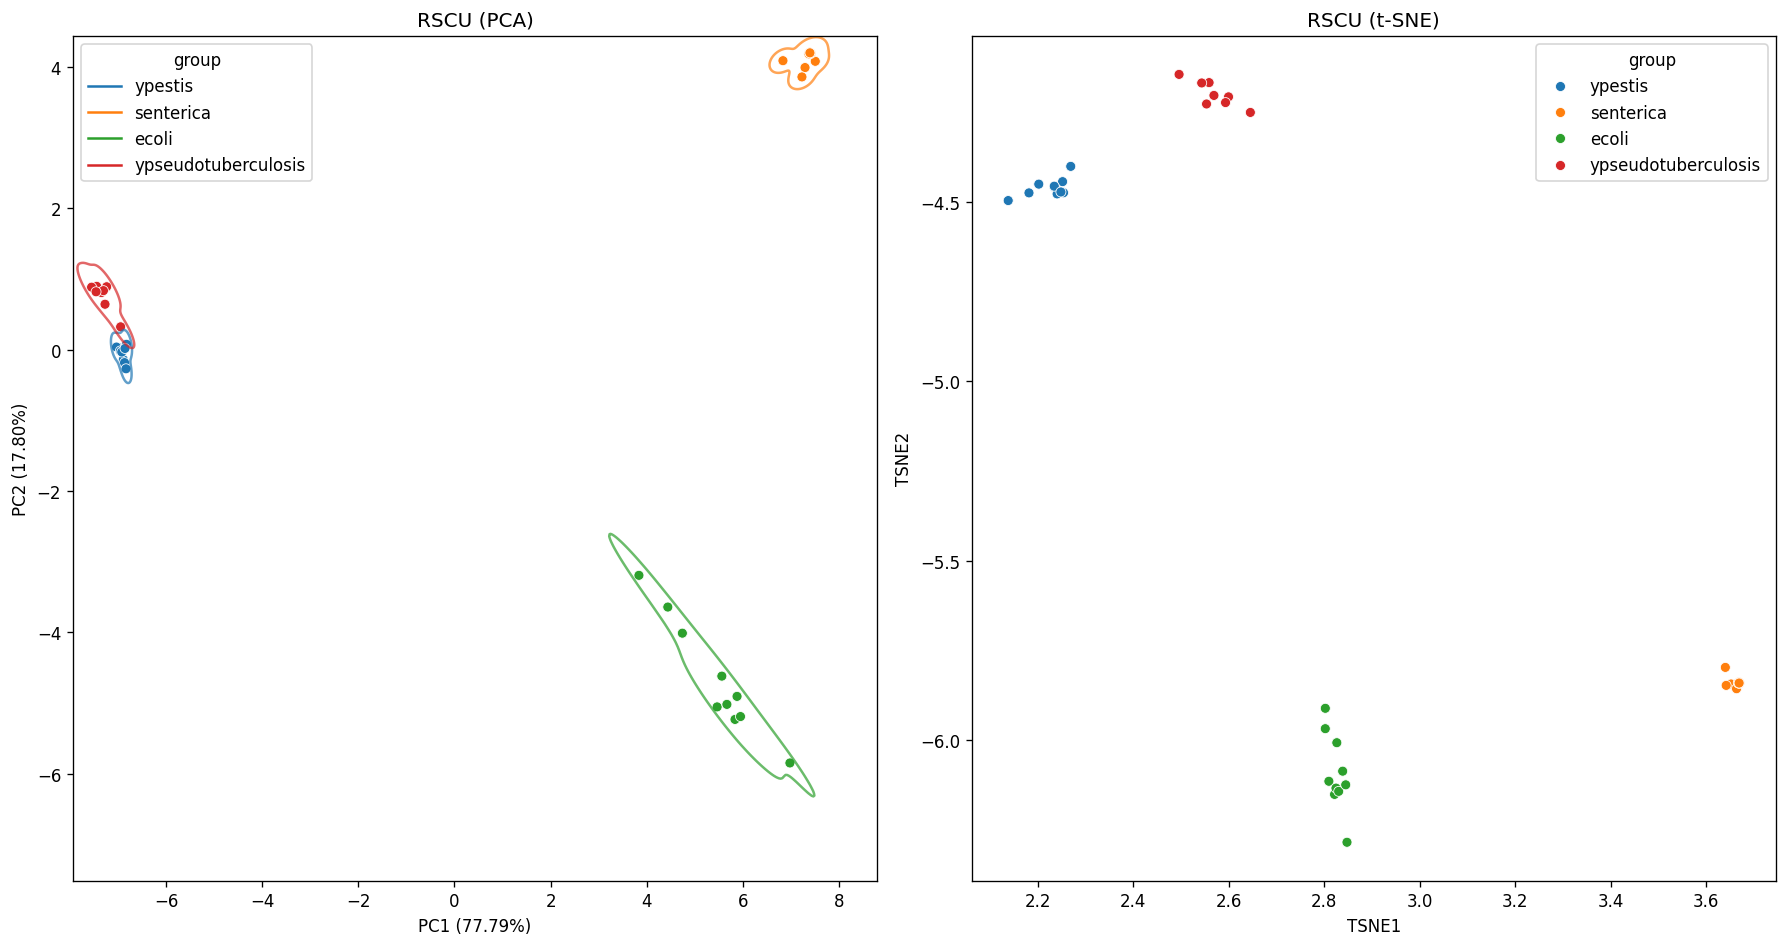

In [78]:
fig, axs = plt.subplots(1, 2, figsize=(15, 8), dpi=120)
axs = axs.ravel()

sns.scatterplot(data=rscu_pca_df, x='PC1', y='PC2', hue='group', ax=axs[0])
sns.kdeplot(data=rscu_pca_df, x='PC1', y='PC2', hue='group', levels=1, alpha=0.7, thresh=0.01, ax=axs[0]) # Optional: disable KDE contours if group sizes are too small
axs[0].set_xlabel(f'PC1 ({rscu_explained_ratio[0]:.2%})')
axs[0].set_ylabel(f'PC2 ({rscu_explained_ratio[1]:.2%})')
axs[0].set_title('RSCU (PCA)')

sns.scatterplot(data=rscu_tsne_df, x='TSNE1', y='TSNE2', hue='group', ax=axs[1])
axs[1].set_title('RSCU (t-SNE)')

plt.tight_layout()


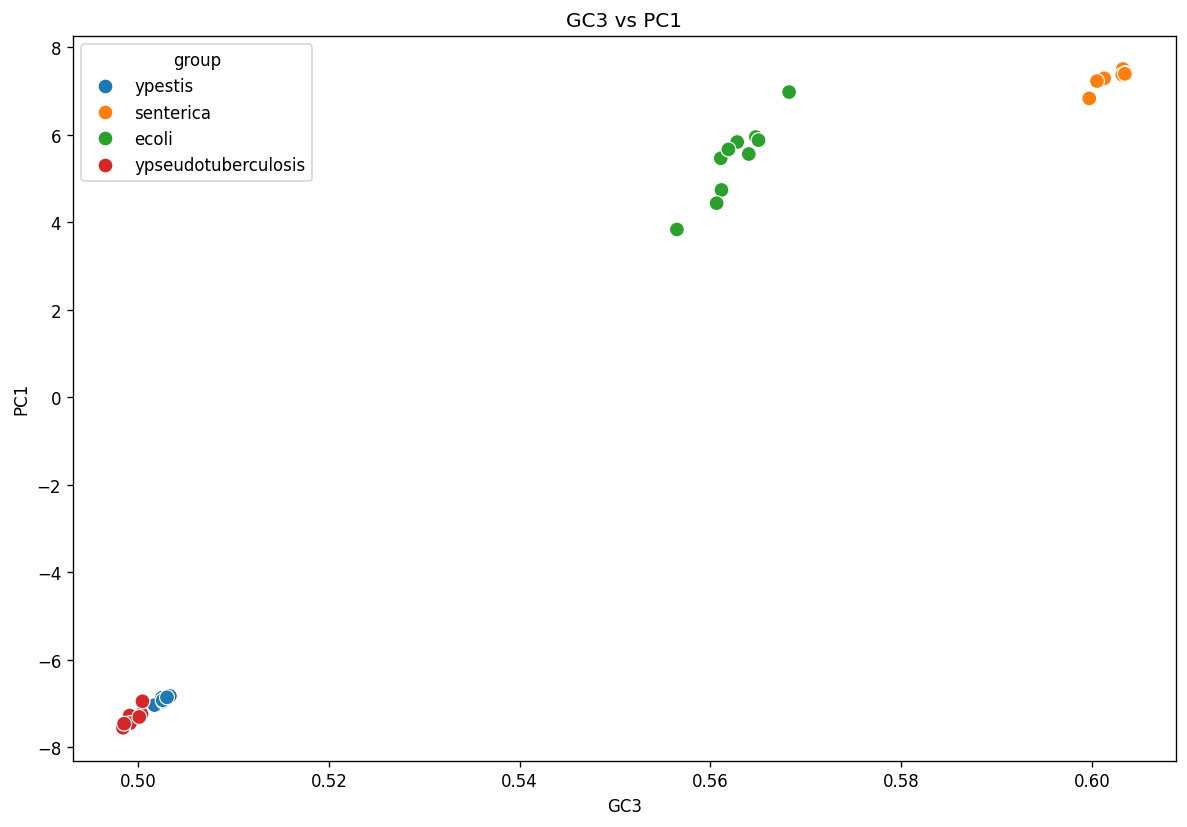

In [ ]:
codons = rscu_df.drop('group', axis=1).columns
gc3_pc1_df = rscu_pca_df[['PC1', 'group']].copy()

gc3_map = {codon: int(codon[2] in ['G', 'C']) for codon in codons}

gc3_pc1_df["GC3"] = (
    rscu_df[codons] * [gc3_map[c] for c in codons]
).sum(axis=1) / rscu_df[codons].sum(axis=1)

plt.figure(figsize=(10,7), dpi=120)
sns.scatterplot(data=gc3_pc1_df, x="GC3", y="PC1", hue="group", s=80)
plt.xlabel("GC3")
plt.ylabel("PC1")
plt.title("GC3 vs PC1")

plt.tight_layout()

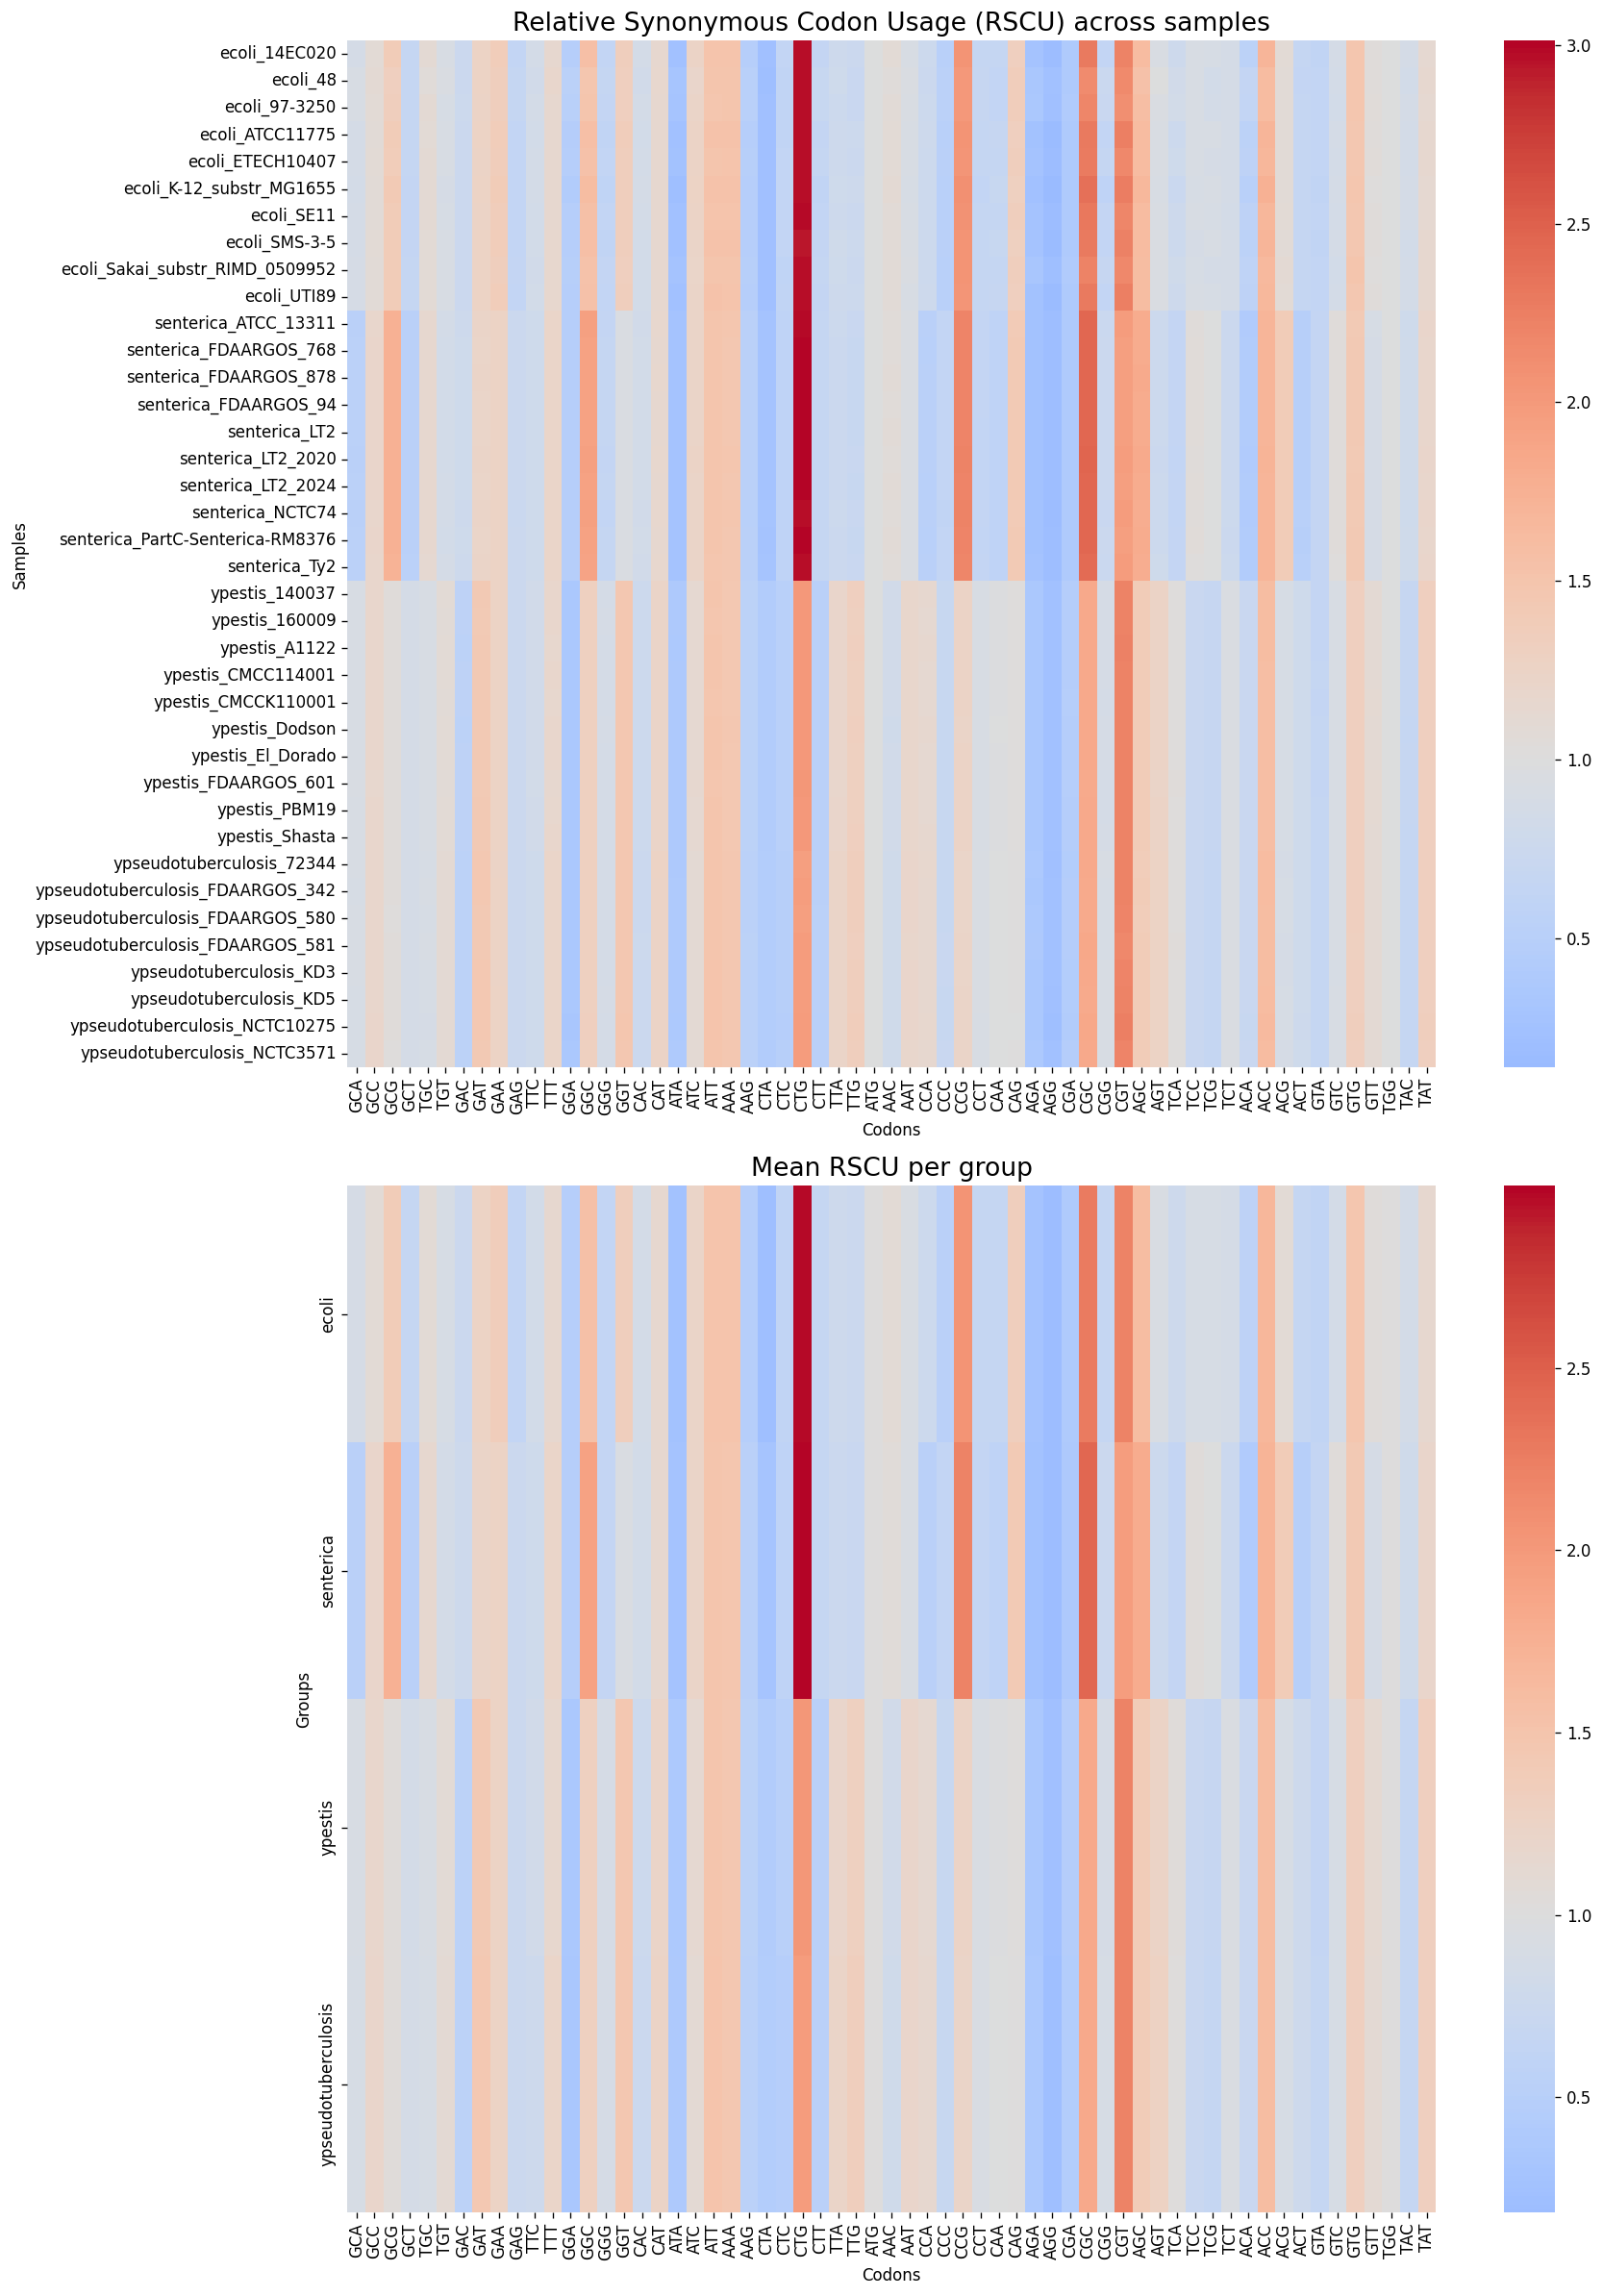

In [76]:
fig, axs = plt.subplots(2, 1, figsize=(15, 20), dpi=120)
axs = axs.ravel()

sns.heatmap(rscu_df.drop('group', axis=1).sort_index(), xticklabels=True, yticklabels=True, ax=axs[0], cmap="coolwarm", center=1)
axs[0].set_title("Relative Synonymous Codon Usage (RSCU) across samples", fontsize=16)
axs[0].set_xlabel("Codons")
axs[0].set_ylabel("Samples")

mean_rscu = rscu_df.groupby("group").mean()

sns.heatmap(mean_rscu, cmap="coolwarm", center=1, ax=axs[1])
axs[1].set_title("Mean RSCU per group", fontsize=16)
axs[1].set_xlabel("Codons")
axs[1].set_ylabel("Groups")


plt.tight_layout()

# Effective Number of Codons (ENC)

In [91]:
enc_df.groupby('group')['enc'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
ecoli,10.0,49.512755,0.425572,48.780256,49.315219,49.398291,49.707811,50.173826
senterica,10.0,48.059781,0.076800,47.971340,48.039993,48.044242,48.048221,48.267727
ypestis,10.0,53.226542,0.043324,53.127889,53.217318,53.229780,53.249294,53.294154
ypseudotuberculosis,8.0,53.137875,0.137311,52.835214,53.127718,53.162292,53.196492,53.281206


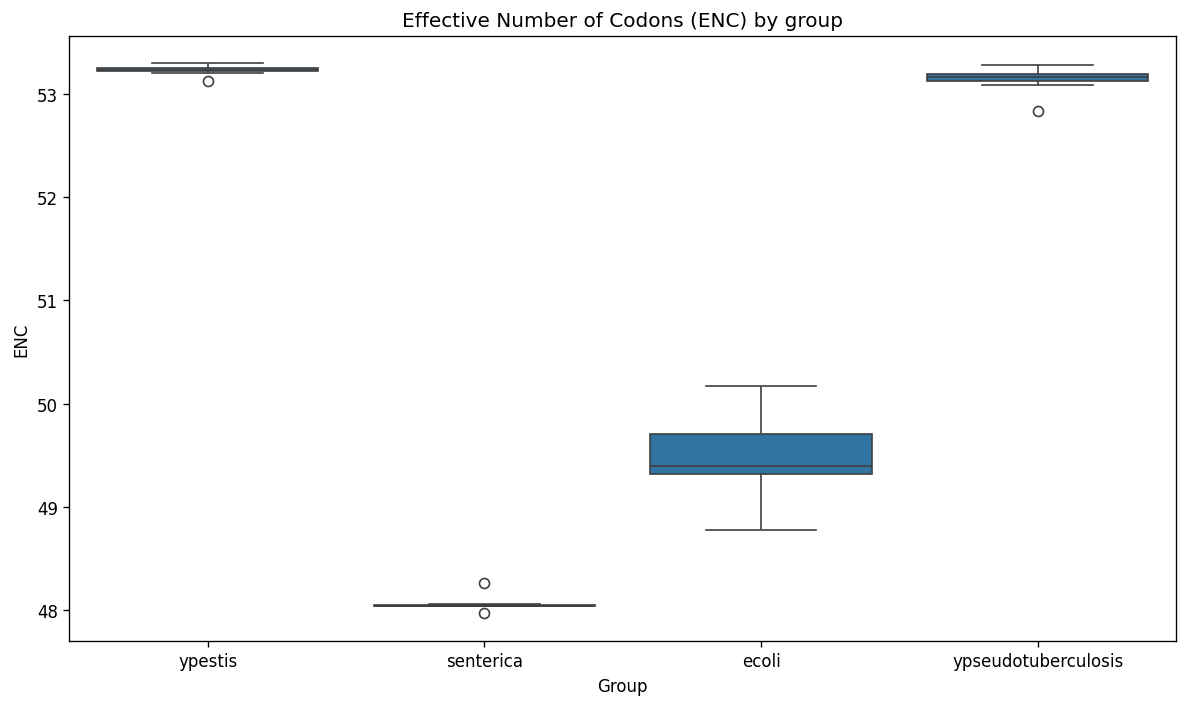

In [93]:
plt.figure(figsize=(10,6), dpi=120)
sns.boxplot(data=enc_df, x="group", y="enc")
plt.xlabel('Group')
plt.ylabel('ENC')
plt.title('Effective Number of Codons (ENC) by group')
plt.tight_layout()

## Genome similarity based on k-mers

Pairwise Mash distances were calculated using 21-mers.

Mash-based distances were used as a complementary genome-wide similarity measure. This allows comparison between codon usage-based clustering and overall genomic similarity.

See the README or `prepare_data.sh` for details.

In [94]:
mash_dist_df = pd.read_csv(f'{WORKDIR}/kmers/mash.dist.tsv', sep='\t', header=None, names=['g1', 'g2', 'dist', 'p', 'shared'])
mash_dist_df['g1'] = mash_dist_df['g1'].map(lambda x: Path(x).stem)
mash_dist_df['g2'] = mash_dist_df['g2'].map(lambda x: Path(x).stem)

dist_df = mash_dist_df.pivot(index='g1', columns='g2', values='dist')
dist_df = dist_df.combine_first(dist_df.T)
dist_df = dist_df.fillna(0.0)

dm = DistanceMatrix(dist_df.values, ids=dist_df.index)
ord_res = pcoa(dm, dimensions=2)
coords = ord_res.samples.iloc[:, :2].copy()
coords.columns = ['PCoA1', 'PCoA2']
coords = add_groups(coords)

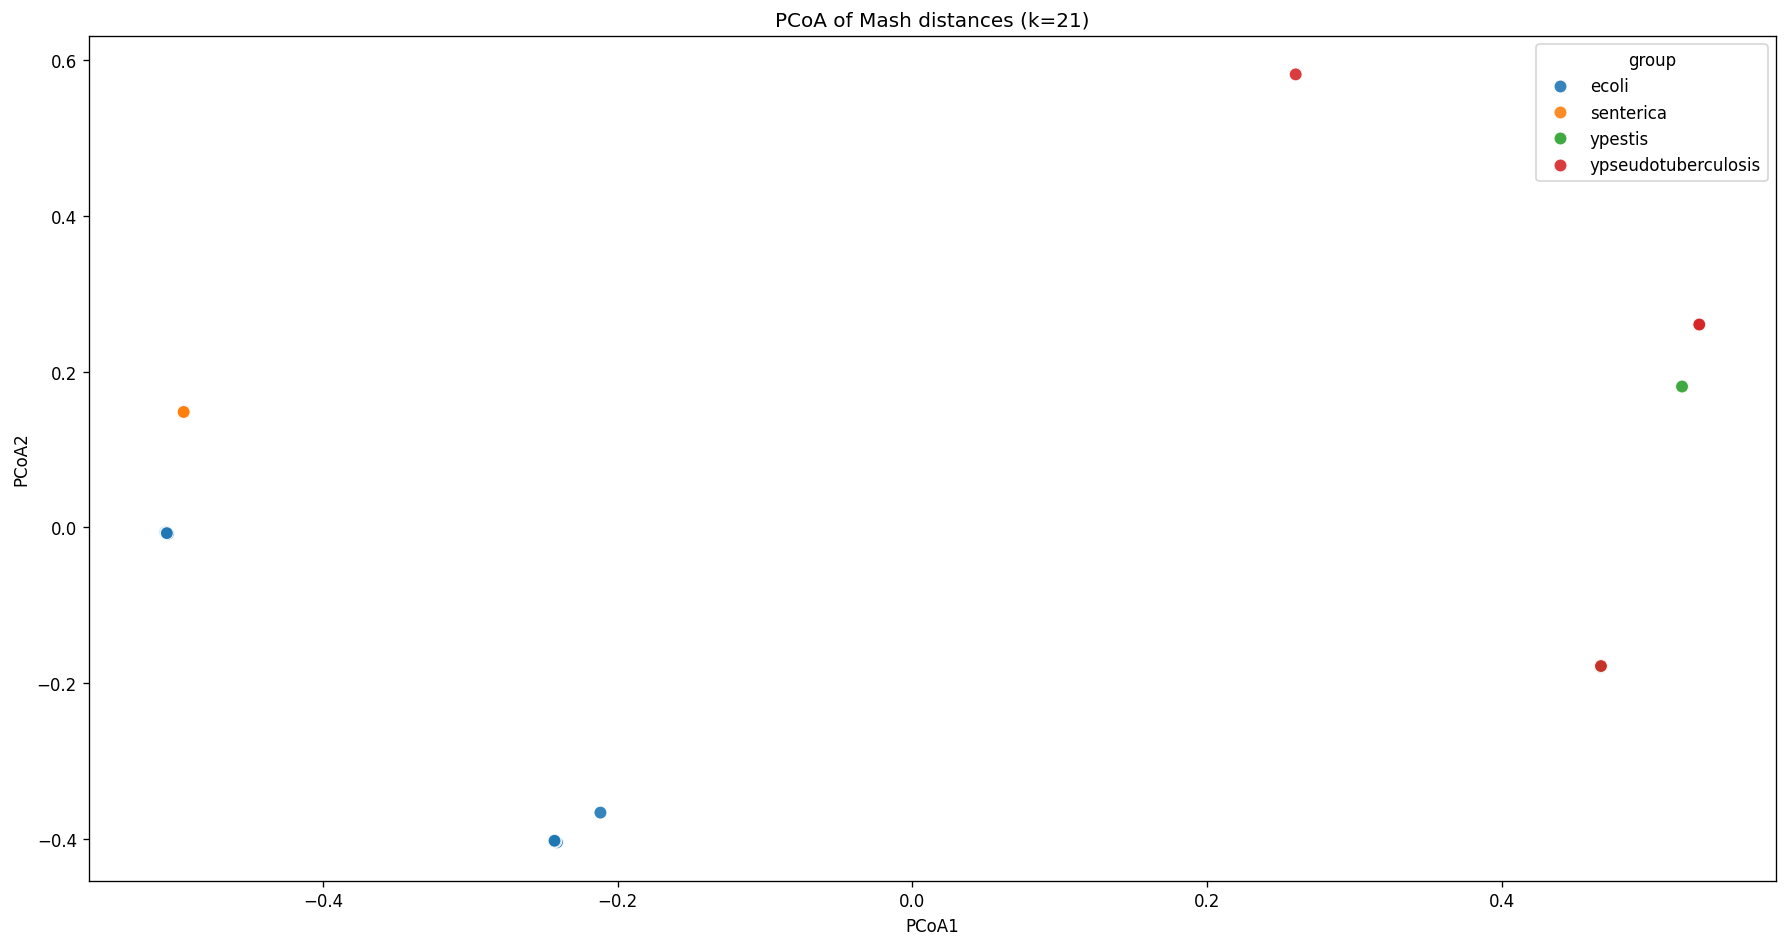

In [95]:
plt.figure(figsize=(15,8), dpi=120)
sns.scatterplot(data=coords, x='PCoA1', y='PCoA2', hue='group', s=60, alpha=0.9)
plt.xlabel(f'PCoA1')
plt.ylabel(f'PCoA2')
plt.title('PCoA of Mash distances (k=21)')
plt.tight_layout()